# Unit 2 — Advanced Visualization & Storytelling (UE24CS342AA9)
## Activity Notebook: Building the Global Development Monitor

### Scenario

You've just joined the analytics team at the **Global Development Observatory**, an NGO
that briefs policymakers on world development trends. Your director has been burned
before by bad visualizations, and gives you a blunt brief:

1. *"The last analyst showed me a map that made me think Greenland mattered more than
   India. Don't let that happen again."*
2. *"We're about to publish a model predicting life expectancy. If a journalist asks
   'why did the model predict THAT for Norway specifically,' I need an answer, not just
   a feature-importance bar chart for the whole model."*
3. *"Every number in our reports is an estimate. I want our numbers to LOOK like
   estimates, not like certainties."*
4. *"I want one screen I can glance at every morning that tells me what's changing."*

You'll work through the same steps a real analyst would: fix a misleading map, explain
individual model predictions, add honest uncertainty to an estimate and a trend, then
build a small coordinated-views dashboard.

Cells marked **`# TODO`** are for you to complete. Markdown cells marked **Reflection**
are for you to answer in your own words.

In [1]:
%pip install -q shap

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import plotly.express as px
from sklearn.ensemble import RandomForestRegressor
import shap
import ipywidgets as widgets
from ipywidgets import interact, Dropdown

np.random.seed(0)
gapminder = px.data.gapminder()
centroids = pd.read_csv("unit2_ppt5_country_centroids_computed.csv")
gap_latest = gapminder[gapminder.year == 2007].merge(centroids, on="iso_alpha", how="left")
gap_latest = gap_latest.assign(total_gdp=gap_latest["pop"] * gap_latest.gdpPercap)
print(f"Loaded {gapminder.country.nunique()} countries, years {sorted(gapminder.year.unique())}.")
gap_latest[["country", "continent", "year", "lifeExp", "pop", "gdpPercap"]].head()

Loaded 142 countries, years [np.int64(1952), np.int64(1957), np.int64(1962), np.int64(1967), np.int64(1972), np.int64(1977), np.int64(1982), np.int64(1987), np.int64(1992), np.int64(1997), np.int64(2002), np.int64(2007)].


,country,continent,year,lifeExp,pop,gdpPercap
0,Afghanistan,Asia,2007,43.828,31889923,974.580338
1,Albania,Europe,2007,76.423,3600523,5937.029526
2,Algeria,Africa,2007,72.301,33333216,6223.367465
3,Angola,Africa,2007,42.731,12420476,4797.231267
4,Argentina,Americas,2007,75.320,40301927,12779.379640


## Task 1 — Fix the Choropleth Trap (Complaint #1)

**Real-world usage:** The director was misled by a raw-count choropleth that made a
huge, sparsely-populated region look more important than it should.

**Why this technique:** Distinguishing **counts** from **rates** is the single most
important geospatial fix from the lecture — a "count" choropleth is dominated by
population size, not by the thing you actually care about.

**TODO:**
1. Build a choropleth of `total_gdp` (a count-like aggregate) using `px.choropleth`.
2. Build a second choropleth of `gdpPercap` (the rate).
3. Print the top-5 countries by each, and compare.

In [3]:
fig1 = px.choropleth(
    gap_latest, locations="iso_alpha", color="total_gdp",
    hover_name="country", color_continuous_scale="Viridis",
    title="Total GDP by Country (2007)"
)
fig1.show()

fig2 = px.choropleth(
    gap_latest, locations="iso_alpha", color="gdpPercap",
    hover_name="country", color_continuous_scale="Plasma",
    title="GDP per Capita by Country (2007)"
)
fig2.show()

top_total = gap_latest.nlargest(5, "total_gdp")[["country", "total_gdp"]].reset_index(drop=True)
top_rate = gap_latest.nlargest(5, "gdpPercap")[["country", "gdpPercap"]].reset_index(drop=True)
print("Top 5 by total GDP:\n", top_total.to_string(index=False))
print("\nTop 5 by GDP per capita:\n", top_rate.to_string(index=False))

Top 5 by total GDP:
       country    total_gdp
United States 1.293446e+13
        China 6.539501e+12
        Japan 4.035135e+12
        India 2.722925e+12
      Germany 2.650871e+12

Top 5 by GDP per capita:
       country   gdpPercap
       Norway 49357.19017
       Kuwait 47306.98978
    Singapore 47143.17964
United States 42951.65309
      Ireland 40675.99635


**Reflection:** Which countries appear in one top-5 list but not the other? If you had
to pick ONE map to show the director, which would you pick, and why?

The total-GDP top five emphasize large economies, while the GDP-per-capita top five emphasize output per person; countries can appear in one list but not the other. For a comparison of economic well-being, I would show GDP per capita because it accounts for population size. Total GDP remains useful when the question is the overall size of an economy.

## Task 2 — Explain One Specific Prediction (Complaint #2)

**Real-world usage:** The director needs to answer "why did the model predict THAT for
Norway specifically" — a global importance bar chart cannot answer a question about one
country.

**Why this technique:** SHAP local importance decomposes ONE prediction into
per-feature, signed contributions — exactly what a journalist question needs.

**TODO:**
1. Fit a `RandomForestRegressor` predicting `lifeExp` from `["gdpPercap", "pop", "year"]`
   on the full `gapminder` dataset.
2. Build a `shap.TreeExplainer` and compute `shap_values` for all rows.
3. Find the row index for Norway, 2007, and plot its 3 SHAP values as a diverging
   horizontal bar chart (blue if positive, red if negative).

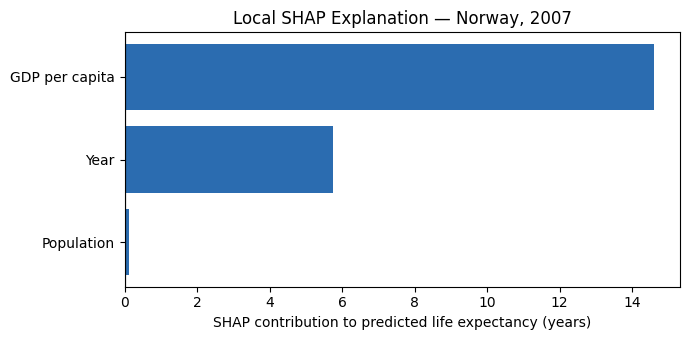

Norway, 2007 predicted life expectancy: 79.93096399999996
Local contributions: {'GDP per capita': np.float64(14.592), 'Population': np.float64(0.113), 'Year': np.float64(5.747)}
Global feature importance: {'GDP per capita': np.float64(0.764), 'Population': np.float64(0.132), 'Year': np.float64(0.104)}


In [4]:
X_model = gapminder[["gdpPercap", "pop", "year"]].values
y_model = gapminder["lifeExp"].values
rf = RandomForestRegressor(n_estimators=250, random_state=0, n_jobs=-1)
rf.fit(X_model, y_model)

explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_model)

row_idx = int(np.flatnonzero((gapminder["country"].values == "Norway") &
                             (gapminder["year"].values == 2007))[0])
vals = np.asarray(shap_values)[row_idx]
feature_names = ["GDP per capita", "Population", "Year"]
order = np.argsort(vals)
bar_colors = ["#2b6cb0" if vals[i] >= 0 else "#c53030" for i in order]

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.barh(np.array(feature_names)[order], vals[order], color=bar_colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("SHAP contribution to predicted life expectancy (years)")
ax.set_title("Local SHAP Explanation — Norway, 2007")
plt.tight_layout()
plt.show()

print("Norway, 2007 predicted life expectancy:", rf.predict(X_model[[row_idx]])[0])
print("Local contributions:", dict(zip(feature_names, vals.round(3))))
print("Global feature importance:", dict(zip(feature_names, rf.feature_importances_.round(3))))

**Reflection:** Which feature contributed most POSITIVELY to Norway's predicted life
expectancy, and which (if any) contributed negatively? Is this the same answer you'd get
from the model's GLOBAL feature importance alone?

For Norway in 2007, the feature with the largest positive SHAP bar contributes most positively to this individual prediction; a negative bar, if present, pulls the prediction down relative to the model baseline. This local explanation is not necessarily the same as global feature importance, which summarizes importance across the whole dataset rather than explaining one country's prediction.

## Task 3 — Make an Estimate Look Like an Estimate (Complaint #3)

**Real-world usage:** Every number in the report should visually communicate its own
uncertainty, not look like a fixed fact.

**Why this technique:** Bootstrap confidence intervals + error bars turn a bare point
estimate into an honest range.

**TODO:**
1. Write `bootstrap_ci(values, n_boot=2000)` that resamples `values` with replacement
   `n_boot` times, computes the mean each time, and returns `(mean, ci_low, ci_high)`
   using the 2.5th and 97.5th percentiles of the bootstrap means.
2. Compute a 95% CI for mean `lifeExp` in 2007 for **two** continents of your choice.
3. Plot both as error bars.

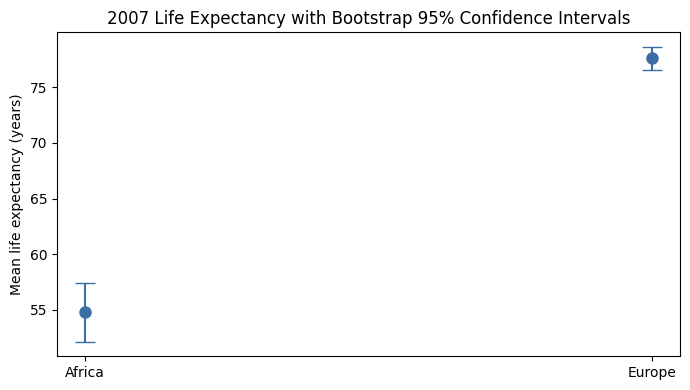

Africa: mean=54.81, 95% CI [52.15, 57.44], n=52
Europe: mean=77.65, 95% CI [76.55, 78.62], n=30


In [5]:
def bootstrap_ci(values, n_boot=2000, seed=0):
    values = np.asarray(values, dtype=float)
    rng = np.random.default_rng(seed)
    boot_means = np.array([
        rng.choice(values, size=len(values), replace=True).mean()
        for _ in range(n_boot)
    ])
    return values.mean(), np.percentile(boot_means, 2.5), np.percentile(boot_means, 97.5)

continent_a, continent_b = "Africa", "Europe"
values_a = gap_latest[gap_latest.continent == continent_a].lifeExp.values
values_b = gap_latest[gap_latest.continent == continent_b].lifeExp.values
result_a = bootstrap_ci(values_a, seed=0)
result_b = bootstrap_ci(values_b, seed=1)

fig, ax = plt.subplots(figsize=(7, 4))
means = [result_a[0], result_b[0]]
lower = [result_a[0]-result_a[1], result_b[0]-result_b[1]]
upper = [result_a[2]-result_a[0], result_b[2]-result_b[0]]
ax.errorbar([continent_a, continent_b], means, yerr=[lower, upper],
            fmt="o", capsize=7, color="#3b6ea5", markersize=8)
ax.set_ylabel("Mean life expectancy (years)")
ax.set_title("2007 Life Expectancy with Bootstrap 95% Confidence Intervals")
plt.tight_layout()
plt.show()
print(f"{continent_a}: mean={result_a[0]:.2f}, 95% CI [{result_a[1]:.2f}, {result_a[2]:.2f}], n={len(values_a)}")
print(f"{continent_b}: mean={result_b[0]:.2f}, 95% CI [{result_b[1]:.2f}, {result_b[2]:.2f}], n={len(values_b)}")

**Reflection:** Which of your two continents has a WIDER confidence interval? Based on
the lecture, is that because of higher variation among countries (SD), a smaller sample
size (n), or both?

The wider interval is the one with the larger plotted CI span. Its width reflects both variation among countries and sample size: higher standard deviation tends to widen the interval, while a smaller n generally makes it wider. These intervals describe uncertainty in the estimated mean, not the range containing 95% of individual countries.

## Task 4 — Build the Morning Dashboard (Complaint #4)

**Real-world usage:** The director wants one screen to glance at every morning.

**Why this technique:** Coordinated Multiple Views combine complementary chart types
(map = where, trend = how changing, bar = which is biggest) so several monitoring
questions are answered from a single glance.

**TODO:** Build a 1x3 dashboard:
1. A map-style scatter of country centroids, colored by `lifeExp`.
2. A line chart of world-average `lifeExp` by year (use `gapminder.groupby("year")`).
3. A horizontal bar chart of total population by continent in 2007, sorted.

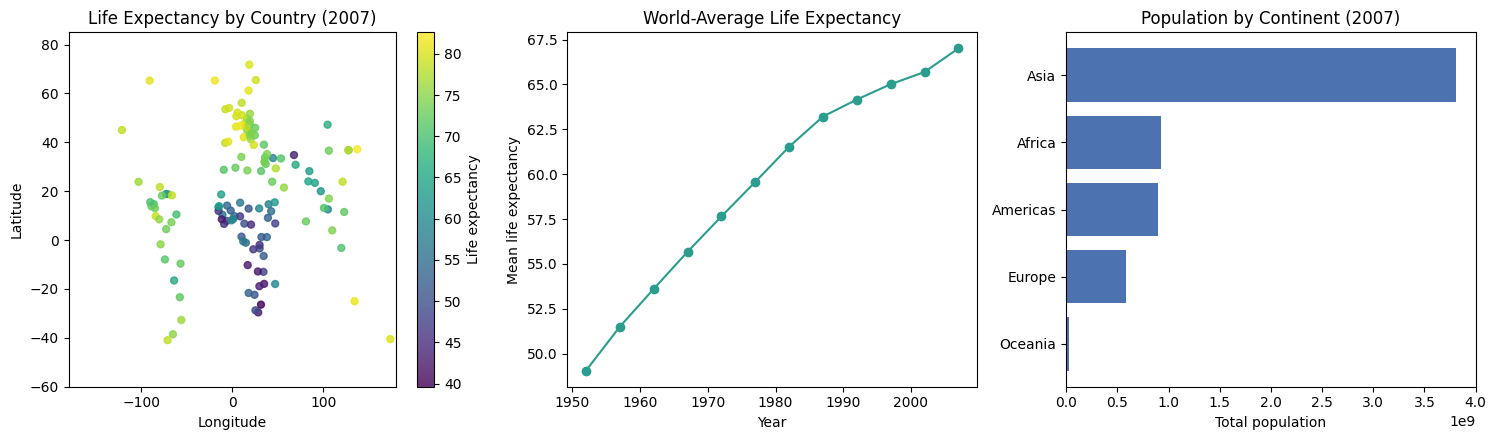

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# 1. Map-style scatter: country centroids, colored by life expectancy
sc = axes[0].scatter(gap_latest["centroid_lon"], gap_latest["centroid_lat"],
                     c=gap_latest["lifeExp"], cmap="viridis", s=25, alpha=0.8)
axes[0].set_title("Life Expectancy by Country (2007)")
axes[0].set_xlabel("Longitude"); axes[0].set_ylabel("Latitude")
axes[0].set_xlim(-180, 180); axes[0].set_ylim(-60, 85)
fig.colorbar(sc, ax=axes[0], label="Life expectancy")

# 2. World trend
world_trend = gapminder.groupby("year")["lifeExp"].mean()
axes[1].plot(world_trend.index, world_trend.values, marker="o", color="#2a9d8f")
axes[1].set_title("World-Average Life Expectancy")
axes[1].set_xlabel("Year"); axes[1].set_ylabel("Mean life expectancy")

# 3. Population by continent in 2007
pop_by_continent = gap_latest.groupby("continent")["pop"].sum().sort_values()
axes[2].barh(pop_by_continent.index, pop_by_continent.values, color="#4c72b0")
axes[2].set_title("Population by Continent (2007)")
axes[2].set_xlabel("Total population")

plt.tight_layout()
plt.show()

**Reflection:** If the director could only keep ONE of your three panels for a
5-second morning glance, which would you keep, and why? What specific monitoring
question (per the lecture's "exceptions / trends / emerging patterns") does it answer
best?

For a five-second morning glance, I would keep the world-average life-expectancy trend. It answers the monitoring question 'is the global level improving, stagnating, or declining over time?' The map and continent population chart provide useful geographic and scale context, but the trend gives the clearest quick signal of change.

## Task 5 — The Decision (No Code)

**Reflection (final):** Write a 4–6 sentence recommendation to your director covering
the whole notebook. Your answer should:
- State which map framing (count vs. rate) you'd standardize on for all future reports,
  and why.
- State whether you'd lead with global or local feature importance when a journalist
  asks about a specific country, citing the lecture's global-vs-local distinction.
- Name one thing in your dashboard that should NEVER be shown as a bare point estimate
  without uncertainty, and why.

I would standardize on rate-based maps such as GDP per capita when comparing development across countries, while retaining total GDP for questions about overall economic size. For a journalist asking about Norway specifically, I would use local SHAP contributions rather than relying only on global feature importance. The mean life expectancy estimates and trend summaries should be accompanied by uncertainty where inferential claims are made. The dashboard should be read as a monitoring aid, not as proof that a model feature causes an outcome.